# 05 — Signal Quality Profiling

**Purpose:** Profile every EnFa signal across its full time range using DuckDB.

Corresponds to `scripts/06_signal_profiles.py` — same logic, step by step.

**What this does:**
- Row count, null count, min/max/mean/std, percentiles for every signal
- Gap ratio — fraction of expected 20-second readings that are missing
- Outlier count — values beyond mean ± 3σ
- Saves `reports/signal_quality_profiles.csv` (used by notebook 07)

**Interactive cells:**
- **Step 2** — change `SIGNAL` and re-run → instant stats for one signal
- **Step 3** — change `CATEGORY` and re-run → all signals in that group
- **Step 4** — batch run all signals (~60-120 min), saves the CSV

In [4]:
import sys
import csv
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from collections import Counter

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from zoro_eda.config import load_config
from zoro_eda.paths import resolve_paths

cfg   = load_config()
paths = resolve_paths(cfg=cfg)

sns.set_theme(style="whitegrid", palette="tab10")
print(f"Project root : {paths.root}")
print(f"Raw data     : {paths.raw_data}")
print(f"Reports      : {paths.reports}")

Project root : C:\Users\dellg\OneDrive\Documents\ZE
Raw data     : C:\Users\dellg\OneDrive\Documents\ZE\data
Reports      : C:\Users\dellg\OneDrive\Documents\ZE\reports


## Step 1: Load signal classification

Notebook 04 already classified all 233 signals into physical categories.
We load that here so every profile row is labelled with its category.

In [5]:
EXCLUDE_STEMS         = frozenset({"A", "_value", "pilot"})
SNAPSHOT_ROW_THRESHOLD = 20
DEFAULT_INTERVAL_S     = 20   # dominant BMS polling rate

def load_category_map(reports_dir: Path) -> dict:
    path = reports_dir / "signal_classification.csv"
    if not path.exists():
        print("WARNING: signal_classification.csv not found")
        return {}
    mapping = {}
    with open(path, encoding="utf-8") as fh:
        for row in csv.DictReader(fh):
            stem = row.get("signal_name", "").strip()
            cat  = row.get("category",    "").strip()
            excl = row.get("exclude",     "").strip().lower()
            if stem:
                mapping[stem] = "EXCLUDE" if excl == "true" else cat
    return mapping

category_map = load_category_map(paths.reports)

counts = Counter(v for v in category_map.values() if v != "EXCLUDE")
print(f"Signals mapped : {len(category_map)}")
print(f"Categories     : {len(counts)}")
print()
for cat, n in sorted(counts.items(), key=lambda x: -x[1])[:15]:
    print(f"  {cat:<35}  {n:>3}")

Signals mapped : 233
Categories     : 50

  thermal_energy                        26
  thermal_power                         20
  heating_return_temp                   17
  heating_supply_temp                   17
  hvac_setpoint                          8
  heating_curve                          8
  chp_gas                                8
  pv_energy                              8
  dhw_temp                               8
  hp_setpoint                            7
  current_rms                            6
  building_energy                        5
  building_power                         5
  unknown                                5
  chp_loss                               5


## Step 2: Profile one signal

**Change `SIGNAL` and re-run this cell.**

DuckDB reads the full CSV in a few seconds and returns complete statistics.

Gap ratio:
- `0.00` = all readings present
- `0.10` = 10 % of expected 20-second readings missing
- `> 0.50` = more than half the data is gone

In [6]:
# ---- change this ----
SIGNAL = "greal_WP1AbtauSek"
# ----------------------

csv_path = paths.raw_data / f"{SIGNAL}.csv"
if not csv_path.exists():
    raise FileNotFoundError(csv_path)

STATS = '''
SELECT
    COUNT(*)                                                       AS row_count,
    COUNT(*) - COUNT(TRY_CAST(_value AS DOUBLE))                   AS null_count,
    ROUND(MIN(TRY_CAST(_value AS DOUBLE)), 4)                      AS val_min,
    ROUND(MAX(TRY_CAST(_value AS DOUBLE)), 4)                      AS val_max,
    ROUND(AVG(TRY_CAST(_value AS DOUBLE)), 4)                      AS val_mean,
    ROUND(STDDEV_SAMP(TRY_CAST(_value AS DOUBLE)), 4)              AS val_std,
    ROUND(APPROX_QUANTILE(TRY_CAST(_value AS DOUBLE), 0.50), 4)    AS p50,
    ROUND(APPROX_QUANTILE(TRY_CAST(_value AS DOUBLE), 0.95), 4)    AS p95,
    MIN(TRY_CAST(_time AS TIMESTAMPTZ))                            AS t_start,
    MAX(TRY_CAST(_time AS TIMESTAMPTZ))                            AS t_end
FROM read_csv(
    '{path}',
    delim=';', header=true, ignore_errors=true
)
WHERE TRY_CAST(_value AS DOUBLE) IS NOT NULL
'''

row = duckdb.sql(STATS.format(path=csv_path.as_posix())).fetchone()
rc, nc, vmin, vmax, vmean, vstd, p50, p95, t_s, t_e = row

dur_s    = (t_e - t_s).total_seconds() if t_s and t_e else 0
expected = int(dur_s / DEFAULT_INTERVAL_S) if dur_s > 0 else 0
gap      = round(max(0.0, 1 - rc / expected), 3) if expected > 0 else 0.0

print(f"Signal   : {SIGNAL}  [{category_map.get(SIGNAL, 'unknown')}]")
print(f"Rows     : {rc:,}   Nulls: {nc:,}")
print(f"Range    : {vmin} → {vmax}")
print(f"Mean/Std : {vmean} / {vstd}")
print(f"Median   : {p50}   P95: {p95}")
print(f"Coverage : {t_s}  →  {t_e}")
print(f"Gap ratio: {gap:.1%}  (expected {expected:,} readings @ {DEFAULT_INTERVAL_S}s)")

Signal   : greal_WP1AbtauSek  [hp_defrost]
Rows     : 302,312   Nulls: 0
Range    : 0.0 → 511.0
Mean/Std : 510.9882 / 2.4589
Median   : 511.0   P95: 511.0
Coverage : 2022-12-14 16:40:41+02:00  →  2026-05-27 10:03:05+03:00
Gap ratio: 94.4%  (expected 5,441,827 readings @ 20s)


## Step 3: Browse by category

**Change `CATEGORY` and re-run.** Profiles every signal in that group.

Categories to try: `hp_defrost` · `hp_temperature` · `battery_soc` ·
`energy_meter` · `outdoor_weather` · `heating_supply` · `pv_generation`

In [7]:
# ---- change this ----
CATEGORY = "hp_defrost"
# ----------------------

in_cat  = [s for s, c in category_map.items() if c == CATEGORY]
files_c = [paths.raw_data / f"{s}.csv" for s in in_cat
           if (paths.raw_data / f"{s}.csv").exists()]
print(f"Category '{CATEGORY}' → {len(files_c)} signals\n")

QUICK = '''
SELECT
    COUNT(*) AS rows,
    ROUND(MIN(TRY_CAST(_value AS DOUBLE)), 3)  AS val_min,
    ROUND(MAX(TRY_CAST(_value AS DOUBLE)), 3)  AS val_max,
    ROUND(AVG(TRY_CAST(_value AS DOUBLE)), 3)  AS val_mean
FROM read_csv(
    '{path}', delim=';', header=true, ignore_errors=true
)
WHERE TRY_CAST(_value AS DOUBLE) IS NOT NULL
'''

rows = []
for fpath in files_c:
    try:
        r = duckdb.sql(QUICK.format(path=fpath.as_posix())).fetchone()
        rows.append({"signal": fpath.stem, "rows": r[0],
                     "min": r[1], "max": r[2], "mean": r[3]})
    except Exception as e:
        rows.append({"signal": fpath.stem, "rows": 0,
                     "min": None, "max": None, "mean": str(e)[:40]})

print(pd.DataFrame(rows).to_string(index=False))

Category 'hp_defrost' → 4 signals

                       signal   rows  min     max     mean
V_real_AbtauTemperaturBetrieb     47  0.0    10.0    5.234
            greal_WP1AbtauSek 302312  0.0   511.0  510.988
            greal_WP2AbtauSek 302312  0.0 11535.0 1178.611
            greal_WP3AbtauSek 302312  0.0 10777.0 2246.795


## Step 4: Batch profile all signals

Runs DuckDB over all ~230 signals across 40 GB. **Expected: 60-120 min.**

Run once. If the output CSV already exists, this cell is a no-op.
The script version (`scripts/06_signal_profiles.py`) does the same thing
from the command line.

In [ ]:
out_path = paths.reports / "signal_quality_profiles.csv"

if out_path.exists():
    print(f"Already exists: {out_path}")
    print("Delete it and re-run to regenerate.")
else:
    csv_files_all = sorted(
        f for f in paths.raw_data.iterdir()
        if f.is_file() and f.suffix.lower() == ".csv"
        and f.stem not in EXCLUDE_STEMS
        and category_map.get(f.stem, "") != "EXCLUDE"
    )
    print(f"Profiling {len(csv_files_all)} signals  (this will take 60-120 min)...")

    FULL_STATS = '''
    SELECT
        COUNT(*) AS row_count,
        COUNT(*) - COUNT(TRY_CAST(_value AS DOUBLE)) AS null_count,
        MIN(TRY_CAST(_value AS DOUBLE))  AS val_min,
        MAX(TRY_CAST(_value AS DOUBLE))  AS val_max,
        AVG(TRY_CAST(_value AS DOUBLE))  AS val_mean,
        STDDEV_SAMP(TRY_CAST(_value AS DOUBLE)) AS val_std,
        APPROX_QUANTILE(TRY_CAST(_value AS DOUBLE), 0.05) AS p05,
        APPROX_QUANTILE(TRY_CAST(_value AS DOUBLE), 0.50) AS p50,
        APPROX_QUANTILE(TRY_CAST(_value AS DOUBLE), 0.95) AS p95,
        MIN(TRY_CAST(_time AS TIMESTAMPTZ)) AS t_start,
        MAX(TRY_CAST(_time AS TIMESTAMPTZ)) AS t_end
    FROM read_csv(
        '{path}', delim=';', header=true, ignore_errors=true
    )
    WHERE TRY_CAST(_value AS DOUBLE) IS NOT NULL
    '''

    con = duckdb.connect()
    con.execute("PRAGMA threads=4")

    profile_rows = []
    t0 = time.time()

    for i, fpath in enumerate(csv_files_all):
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{len(csv_files_all)}  elapsed={time.time()-t0:.0f}s")
        cat = category_map.get(fpath.stem, "unknown")
        try:
            r  = con.execute(FULL_STATS.format(path=fpath.as_posix())).fetchone()
            rc = int(r[0] or 0)
            if rc < SNAPSHOT_ROW_THRESHOLD:
                profile_rows.append({"signal_name": fpath.stem, "category": cat,
                                     "row_count": rc, "notes": f"snapshot ({rc} rows)"})
                continue
            t_s, t_e = r[9], r[10]
            dur_s = (t_e - t_s).total_seconds() if t_s and t_e else 0
            exp   = int(dur_s / DEFAULT_INTERVAL_S) if dur_s > 0 else 0
            gap   = round(max(0.0, 1 - rc / exp), 4) if exp > 0 else 0.0
            profile_rows.append({
                "signal_name": fpath.stem, "category": cat,
                "row_count": rc, "null_count": int(r[1] or 0),
                "val_min": r[2],  "val_max": r[3],
                "val_mean": r[4], "val_std": r[5],
                "p05": r[6], "p50": r[7], "p95": r[8],
                "start_time": str(t_s), "end_time": str(t_e),
                "gap_ratio": gap, "notes": "ok",
            })
        except Exception as exc:
            profile_rows.append({"signal_name": fpath.stem, "category": cat,
                                  "row_count": 0, "notes": str(exc)[:80]})

    con.close()
    df_all = pd.DataFrame(profile_rows)
    df_all.to_csv(out_path, index=False)
    ok_n = (df_all["notes"] == "ok").sum()
    print(f"\nDone. {ok_n} signals profiled. Saved: {out_path}")

## Step 5: Quality overview plots

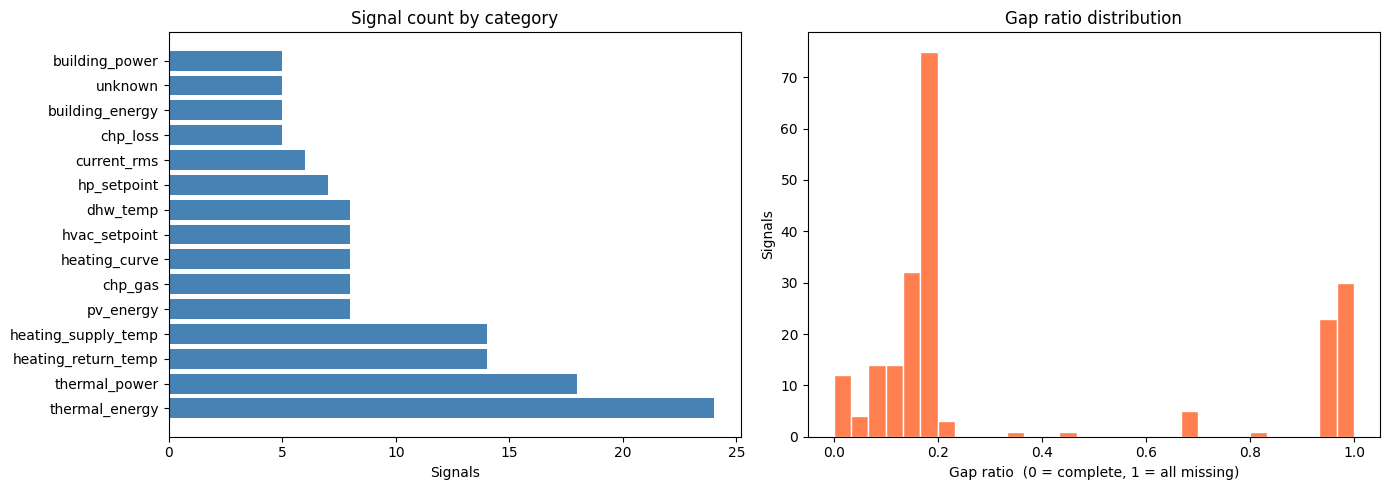

Signals with >10% gap ratio: 185
                  signal_name      category  row_count  gap_ratio
       greal_Administrator_HT control_param         42        1.0
         greal_Nachtabsenkung night_setback         42        1.0
       greal_JalousienMaxWind control_param         37        1.0
      V_real_NachtabsenkungY4 night_setback         39        1.0
                  V_realAZmax   hp_setpoint         40        1.0
       V_real_minVorlaufTempK heating_curve         45        1.0
        V_real_minVorlaufTemp heating_curve         43        1.0
               V_real_minATY4 hvac_setpoint         40        1.0
          V_realSollTempAZmax   hp_setpoint         40        1.0
        V_real_maxVorlaufTemp heating_curve         42        1.0
       V_real_maxVorlaufTempK heating_curve         45        1.0
      V_real_maxVorlaufTempY4 heating_curve         40        1.0
                 V_real_minAT hvac_setpoint         41        1.0
V_real_AbtauTemperaturBetrieb    hp_defrost

In [8]:
profiles_path = paths.reports / "signal_quality_profiles.csv"
if not profiles_path.exists():
    print("Run Step 4 first.")
else:
    pf  = pd.read_csv(profiles_path)
    ok  = pf[pf["notes"] == "ok"].copy()
    ok["gap_ratio"] = pd.to_numeric(ok.get("gap_ratio", 0), errors="coerce").fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cat_counts = ok["category"].value_counts().head(15)
    axes[0].barh(cat_counts.index, cat_counts.values, color="steelblue")
    axes[0].set_title("Signal count by category")
    axes[0].set_xlabel("Signals")

    axes[1].hist(ok["gap_ratio"], bins=30, color="coral", edgecolor="white")
    axes[1].set_title("Gap ratio distribution")
    axes[1].set_xlabel("Gap ratio  (0 = complete, 1 = all missing)")
    axes[1].set_ylabel("Signals")

    plt.tight_layout()
    plots_dir = paths.reports / "plots"
    plots_dir.mkdir(exist_ok=True)
    plt.savefig(plots_dir / "05_signal_quality_overview.png", dpi=150, bbox_inches="tight")
    plt.show()

    problem = ok[ok["gap_ratio"] > 0.10].sort_values("gap_ratio", ascending=False)
    print(f"Signals with >10% gap ratio: {len(problem)}")
    if len(problem):
        cols = [c for c in ["signal_name","category","row_count","gap_ratio"] if c in problem]
        print(problem[cols].head(20).to_string(index=False))

## Key findings

After running Step 4:
- Signals with gap_ratio > 0.10 need investigation before modeling
- Signals with val_min == val_max are stuck / always-on → exclude from forecasting
- Categories with many signals are the richest subsystems for MPC

These profiles feed directly into notebook 06 (resampling) and notebook 07 (full EDA).